# Using the new sampler classes

Just a simple notebook here where we use the implemented samplers.

## Linear regression

One of the easiest models we can look at is a simple linear regression with a Gaussian prior on the coefficients.
\begin{align}
\pi(\mathbf{y} \vert \boldsymbol{\beta},X) = \mathcal{N}(X\boldsymbol{\beta},\sigma^2I),  \ \ \ \ \pi(\boldsymbol{\beta})=\mathcal{N}(0,\alpha^2I).
\end{align}

All the sampler need is the gradient of the log-posterior 
\begin{align}
\nabla_{\boldsymbol{\beta}} \ U(\boldsymbol{\beta}) &= \nabla_{\boldsymbol{\beta}} \ \left[\log \mathcal{N}(X\boldsymbol{\beta},\sigma^2I) + \log \mathcal{N}(0,\alpha^2I)\right] \\
&= \nabla_{\boldsymbol{\beta}} \ \left[ C(\sigma^2) -\frac{1}{2}\left(\frac{1}{\sigma^2}(\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})\right) - \frac{1}{2}\left(\frac{\boldsymbol{\beta}^T\boldsymbol{\beta}}{\alpha^2}\right) \right],
\end{align}
where $C(\sigma^2)$ is some constant that depend on \sigma^2, which we for now take as fixed.

In [31]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 100
alpha = 2.0
sigma = 2.0
X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon


In [32]:
beta

array([ 0.52427408,  0.44419917, -2.13335417, -3.51228757, -2.00935043,
       -0.76689167,  1.92054275, -2.6024038 , -1.7564844 , -0.19539692,
       -1.82998106, -2.5477021 ,  1.27241147,  3.74119025,  2.17340035,
        1.87618506,  0.52939854,  1.46256141, -1.17573529, -2.25825554,
        0.95862964,  2.40545543, -1.90225986, -1.92576463, -1.74050843,
        3.66157594,  2.43384676, -0.44220752, -0.19622247,  0.33476664,
       -1.68690556, -1.00029033,  0.74279305, -1.35426425,  0.81727546,
        0.232664  , -2.25096793, -3.79363955,  3.39991636,  0.40576129,
        1.42353329,  1.06479178,  1.84606472, -2.76425682,  2.17431564,
        2.98706313,  0.44957739,  1.46459915, -1.37498709, -1.75083382,
       -4.85819937, -0.6155385 ,  0.22035957,  0.09637653,  0.84428813,
        1.03506425,  2.2183975 ,  1.51393323,  2.15219562,  3.92356071,
        2.55829551,  2.49247658, -2.51084129, -0.55965123,  0.72989092,
        1.13671451, -0.94976593, -1.7662033 ,  3.92895217, -1.11

In [ ]:
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta,y,X,sigma,alpha):
    yhat = jnp.matmul(X, beta)
    res = y-yhat
    restres = jnp.matmul(jnp.transpose(res),res)
    btb = jnp.matmul(jnp.transpose(beta),beta)
    u = (restres / sigma**2) + (btb / alpha**2)
    return 0.5*u

u = partial(target,y = y, X = X, sigma = sigma, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [ ]:
# Now setting up sampler
from sazz.samplers.AutomaticZigZagSampler import AutomaticZigZagSampler

sampler = AutomaticZigZagSampler(N=20000,D=d,grad_target=d_target,gamma=0.000)
sampler.sample()

In [ ]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 0
i2 = 1
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))


In [ ]:
points = sampler.getSamples(N_samples = 40000)

In [ ]:
plt.scatter(points[30000:, i1], points[30000:, i2], alpha=0.5, label="Samples",s=0.5)
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)

In [ ]:
plt.plot(sampler.Time)

In [ ]:
sampler.Position.max()

In [ ]:
sampler.t_max

## Sticky Automatic ZigZag

In [ ]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 2000
d0 = 5 # Active components
alpha = 2.0
sigma = 2.0
X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta_a = np.random.normal(0,alpha,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0)))
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And we need the kappa parameters for freezing times
weights = np.full((d),d0/(d),float)
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero

In [ ]:
np.sum(X**2, axis=0)/sigma**2 + 1/alpha**2

In [ ]:
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta,y,X,sigma,alpha):
    yhat = jnp.matmul(X, beta)
    res = y-yhat
    restres = jnp.matmul(jnp.transpose(res),res)
    btb = jnp.matmul(jnp.transpose(beta),beta)
    u = (restres / sigma**2) + (btb / alpha**2)
    return 0.5*u

u = partial(target,y = y, X = X, sigma = sigma, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [ ]:
# Now setting up sampler
from sazz.samplers.StickyAutomaticZigZagSampler import StickyAutomaticZigZagSampler

sampler = StickyAutomaticZigZagSampler(N=10000,D=d,grad_target=d_target, kappa=kappa, gamma=0.000)
sampler.Velocity[0,:] = 0.1*sampler.Velocity[0,:]
sampler.sample()

In [ ]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 1
i2 = 2
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))
plt.scatter(Position[0,i1], Position[0,i2],color="red")

In [ ]:
plt.plot(Position[:,i1])

In [ ]:
plt.scatter(points[20000:, i1], points[20000:, i2], alpha=0.5, label="Samples",s=0.5)
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)

## Logistic regression

In [3]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 500
d = 2000
d0 = 5 # Active components
alpha_draw = 4
alpha = 10

X = np.random.randn(n, d)
X = (X - X.mean(0)) / X.std(0)
beta_a = np.random.normal(0,alpha_draw,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0))).squeeze()
linear_predictor = X @ beta
p = 1.0/(1+np.exp(-linear_predictor))
y = np.random.binomial(1,p,n)

#y = X @ beta + epsilon

# And we need the kappa parameters for freezing times
#weights = np.full((d),d0/(d),float) # Expected sparsity level
weights = np.full(d, 0.2)  # or 0.01
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero
#kappa = 1 * np.sqrt(n) * weights / (1 - weights)

In [8]:
np.random.exponential(1.0 / kappa[1].item())

35.19199583991604

In [9]:
# Now log-likelihood

import jax
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta, temperature, y, X, alpha):
    eta = jnp.matmul(X, beta)              # (n,)
    log_lik = jnp.sum(y * jax.nn.log_sigmoid(eta) + (1-y) * jax.nn.log_sigmoid(-eta))
    prior = -(beta @ beta) / alpha**2
    return -(temperature * log_lik + prior)

u = partial(target,y = y, X = X, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))

In [11]:
# Now setting up sampler
from sazz.samplers.StickyAutomaticZigZagSampler import StickyAutomaticZigZagSampler
from sazz.samplers.AutomaticZigZagSampler import AutomaticZigZagSampler

sampler = StickyAutomaticZigZagSampler(N=100000,D=d,grad_target=d_target, kappa=kappa, gamma=0.000,t0=00.001)
#sampler = AutomaticZigZagSampler(N=10000,D=d,grad_target=d_target, gamma=0.0)
sampler.Position[0,:] = beta # This works, should also try tempering
#sampler.Position[0,:] = np.random.normal(0,0.1,size=d)
sampler.sample() 

Sticky Zig-Zag time:   0%|          | 0/100000 [00:00<?, ?iter/s]

KeyboardInterrupt: 

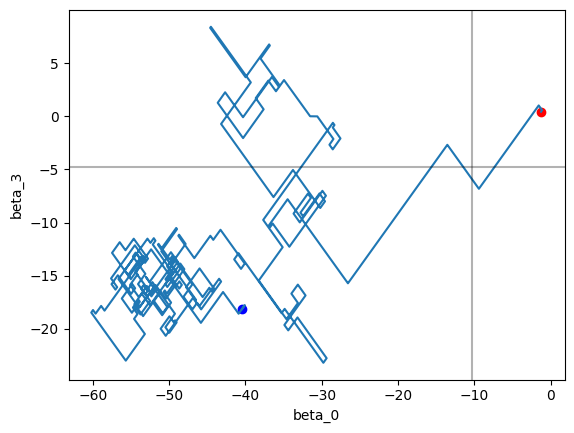

In [44]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 0
i2 = 3
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))
plt.scatter(Position[0,i1], Position[0,i2],color="red")
plt.scatter(Position[-1,i1], Position[-1,i2],color="blue")

In [ ]:
i1 = 0
plt.plot(Position[:,i1])
plt.axhline(beta[i1],color="red")

## Temperature

In [ ]:
import numpy as np
t0 = 20.0

t = 19.0
s= np.clip(t/t0,0.0,1.0)**2


In [ ]:
s